# Main Notebook for Inference on Z Boson Mass from data

In [4]:
# Importing Libraries
import numpy as np 
import matplotlib.pyplot as plt
from dynesty import plotting as dyplot

# Importing data and model
from reconstruction import m_inv_mass2
from model import model

## EMCEE Implementation (Monte Carlo Markov Chain)

In [6]:
# Importing Results from mcmc_fitting
from mcmc_fitting import samples, bin_edges, bin_centers

best_fit = np.median(samples, axis=0)
print(f"Best Fit Parameters (MCMC): {best_fit}")

100%|██████████| 3000/3000 [07:38<00:00,  6.54it/s]


Best Fit Parameters (MCMC): [9.07325950e+01 1.10256597e+00 1.39934291e+00 1.11417917e+04
 6.71174273e+00]


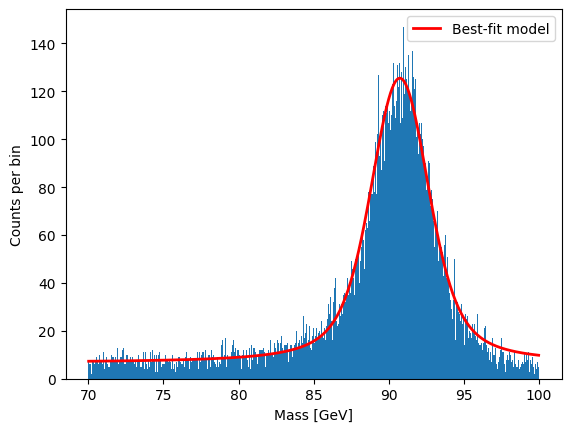

In [7]:
# Plotting 
plt.hist(np.sqrt(m_inv_mass2), bins=500, range = (70,100))
plt.plot(bin_centers, model(bin_centers, *best_fit), color="red", lw=2, label="Best-fit model") 
plt.xlabel("Mass [GeV]") 
plt.ylabel("Counts per bin") 
plt.legend() 
plt.show()

In [16]:
param_names = ["m0", "gamma", "sigma", "Nsig", "Nbg"]

# Posterior median + std
median_params = np.median(samples, axis=0)
std_params = np.std(samples, axis=0)

print("Posterior median ± std (MCMC):")
for name, median, std in zip(param_names, median_params, std_params):
    print(f"{name} = {median:.3f} ± {std:.3f}")


# Credible intervals (16-84%)
q16, q50, q84 = np.percentile(samples, [16, 50, 84], axis=0)

print("\nPosterior 16-50-84% credible intervals (MCMC):")
for i, name in enumerate(param_names):
    print(f"{name} = {q50[i]:.3f} +{q84[i]-q50[i]:.3f} -{q50[i]-q16[i]:.3f}")

Posterior median ± std (MCMC):
m0 = 90.730 ± 2.071
gamma = 1.188 ± 1.015
sigma = 1.430 ± 0.968
Nsig = 11065.783 ± 2556.958
Nbg = 6.894 ± 19.105

Posterior 16-50-84% credible intervals (MCMC):
m0 = 90.730 +0.337 -0.408
gamma = 1.188 +1.148 -0.372
sigma = 1.430 +0.925 -0.472
Nsig = 11065.783 +907.708 -2273.305
Nbg = 6.894 +7.567 -1.317


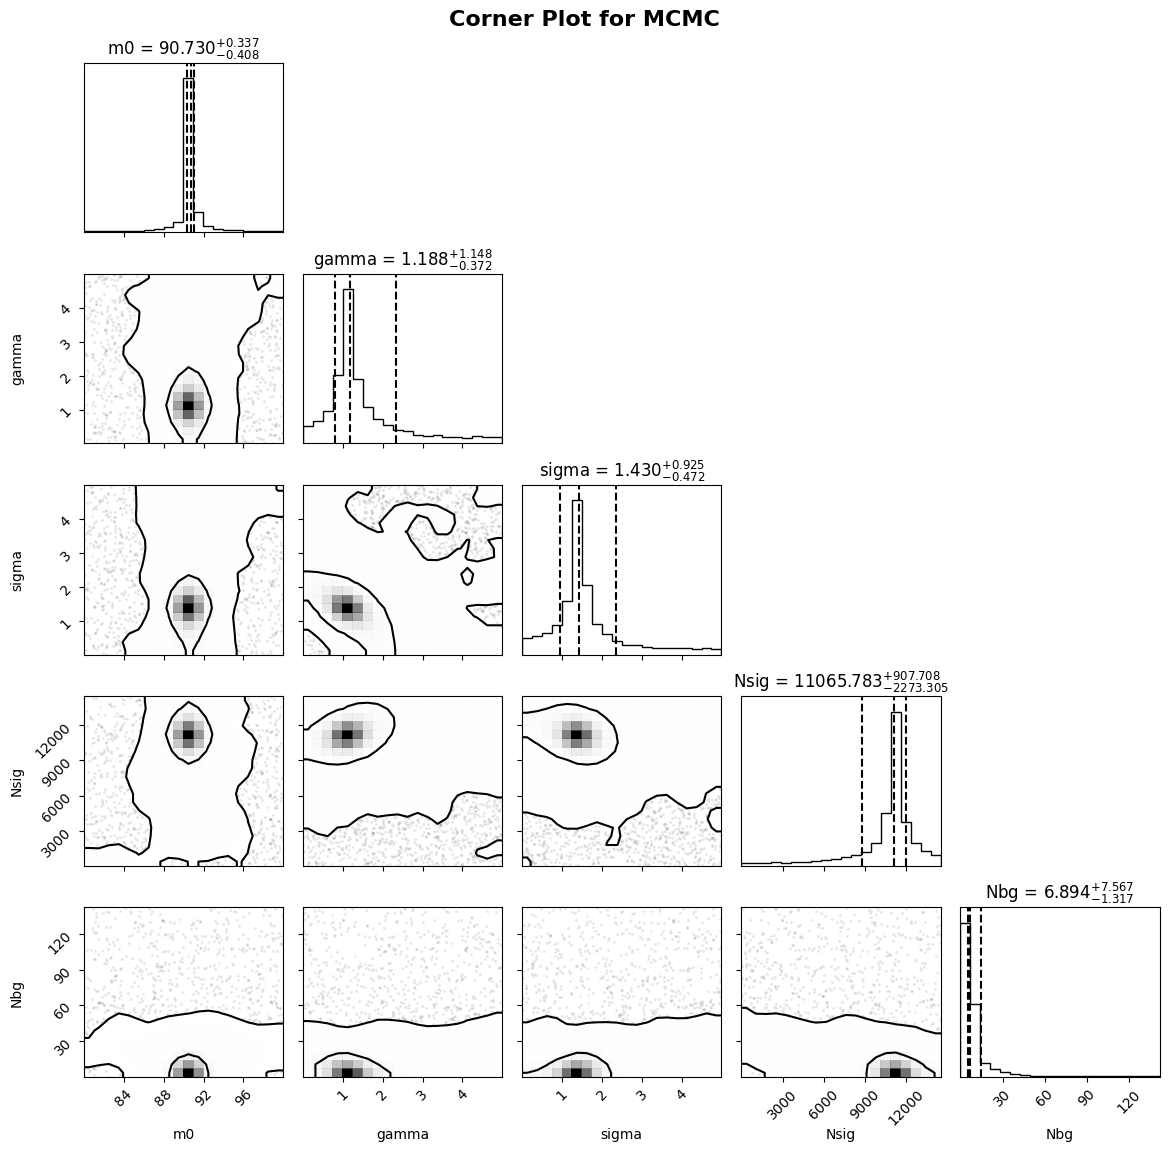

In [20]:
# Corner plot for MCMC

import corner

fig = corner.corner(
    samples,
    labels=param_names,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95],
    smooth=1.0
)

fig.suptitle("Corner Plot for MCMC", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()

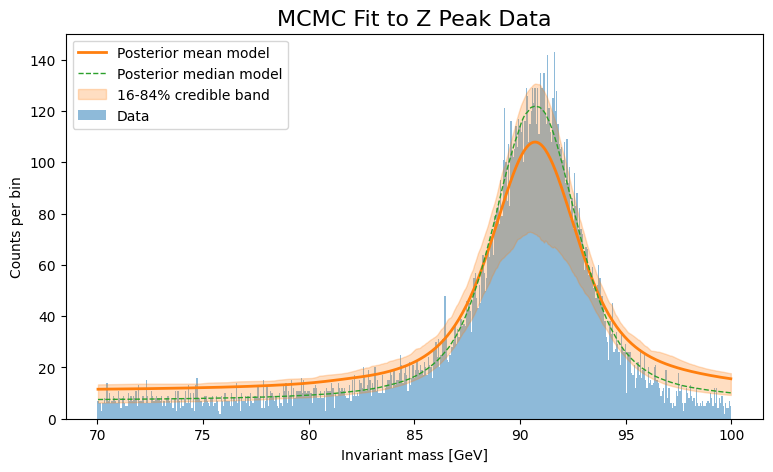

In [18]:
# Plot model with uncertainty band
bin_centers_arr = 0.5 * (bin_edges[:-1] + bin_edges[1:])
observed_counts, _ = np.histogram(np.sqrt(m_inv_mass2), bins=bin_edges)
width = np.diff(bin_edges)[0]

# Draw posterior samples to get model envelope
n_draw = 500
indices = np.random.choice(len(samples), size=n_draw, replace=True)
models = np.array([model(bin_centers_arr, *samples[i]) for i in indices])
lower = np.percentile(models, 16, axis=0)
upper = np.percentile(models, 84, axis=0)
median_model = np.percentile(models, 50, axis=0)
mean_model = np.mean(models, axis=0)

# Plot histogram and model bands
plt.figure(figsize=(9,5))
plt.bar(bin_centers_arr, observed_counts, width=width, alpha=0.5, label="Data")
plt.plot(bin_centers_arr, mean_model, color='C1', lw=2, label="Posterior mean model")
plt.plot(bin_centers_arr, median_model, color='C2', lw=1, ls='--', label="Posterior median model")
plt.fill_between(bin_centers_arr, lower, upper, color='C1', alpha=0.25, label="16-84% credible band")
plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Counts per bin")
plt.legend()
plt.title("MCMC Fit to Z Peak Data", fontsize=16)
plt.show()

## Dynesty Implementation (Nested Sampling)

In [8]:
# Importing Results from dynesty_fitting
from dynesty_fitting import results, bin_edges, bin_centers

11673it [02:25, 79.98it/s, +500 | bound: 61 | nc: 1 | ncall: 49317 | eff(%): 24.936 | loglstar:   -inf < 41887.985 <    inf | logz: 41865.350 +/-  0.214 | dlogz:  0.001 >  0.509]


In [9]:

# Histogram of observed data
observed_counts, _ = np.histogram(np.sqrt(m_inv_mass2), bins=bin_edges)

# Prepare arrays
samples = results.samples            # (nsamp, 5): [m0, gamma, sigma, Nsig, Nbg]
logw = results.logwt                 # (nsamp,): log-weights for each sample

# Stable normalized weights
w = np.exp(logw - np.max(logw))
w /= w.sum()

# Weighted mean (posterior mean) parameters
m0, gamma, sigma, Nsig, Nbg = np.average(samples, axis=0, weights=w)

# Standard deviation of the parameters (posterior std)
std_m0, std_gamma, std_sigma, std_Nsig, std_Nbg = np.sqrt(np.average((samples - 
                        [m0, gamma, sigma, Nsig, Nbg])**2, axis=0, weights=w))

x = np.asarray(bin_centers)
obs = np.asarray(observed_counts, dtype=float)
width = np.diff(bin_edges)[0]

# Model from posterior-mean parameters (model returns counts per bin)
model_mean = model(x, m0, gamma, sigma, Nsig, Nbg)

# Print best-fit parameters
print(f"Posterior mean parameters:")
print(rf"m0 = {m0:.2f} +- {std_m0:.2f} GeV")
print(rf"gamma = {gamma:.2f} +- {std_gamma:.2f} GeV")
print(rf"sigma = {sigma:.2f} +- {std_sigma:.2f} GeV")
print(rf"Nsig = {Nsig:.2f} +- {std_Nsig:.2f}")
print(rf"Nbg = {Nbg:.2f} +- {std_Nbg:.2f}")

print("The error is the standard deviation, not quantile based. " \
"Since the model differs from a Gaussian,\n the standard deviation may not " \
"capture the full uncertainty. Quantile based erorrs can be seen \n in the corner plot.")


Posterior mean parameters:
m0 = 90.73 +- 0.03 GeV
gamma = 1.10 +- 0.09 GeV
sigma = 1.40 +- 0.08 GeV
Nsig = 11132.87 +- 158.06
Nbg = 6.71 +- 0.27
The error is the standard deviation, not quantile based. Since the model differs from a Gaussian,
 the standard deviation may not capture the full uncertainty. Quantile based erorrs can be seen 
 in the corner plot.


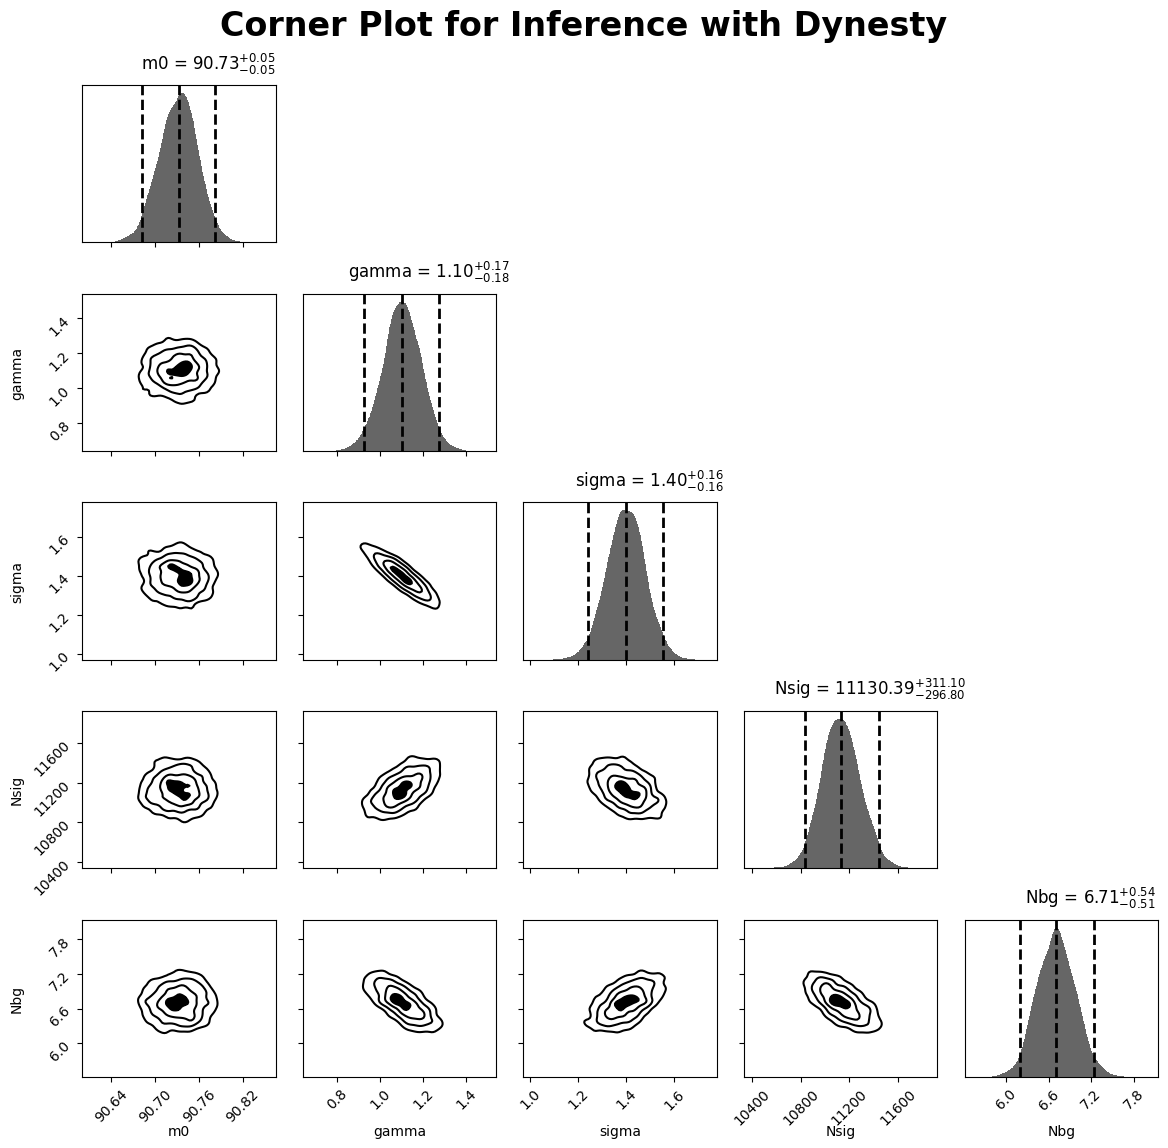

In [10]:
# Corner Plot
param_labels = ['m0', 'gamma', 'sigma', 'Nsig', 'Nbg']
figc, axesc = dyplot.cornerplot(results, show_titles=True, labels=param_labels, title_kwargs={"x": 0.65, "y": 1.05})
figc.suptitle("Corner Plot for Inference with Dynesty", fontsize=24, fontweight='bold')
figc.tight_layout()
plt.show()

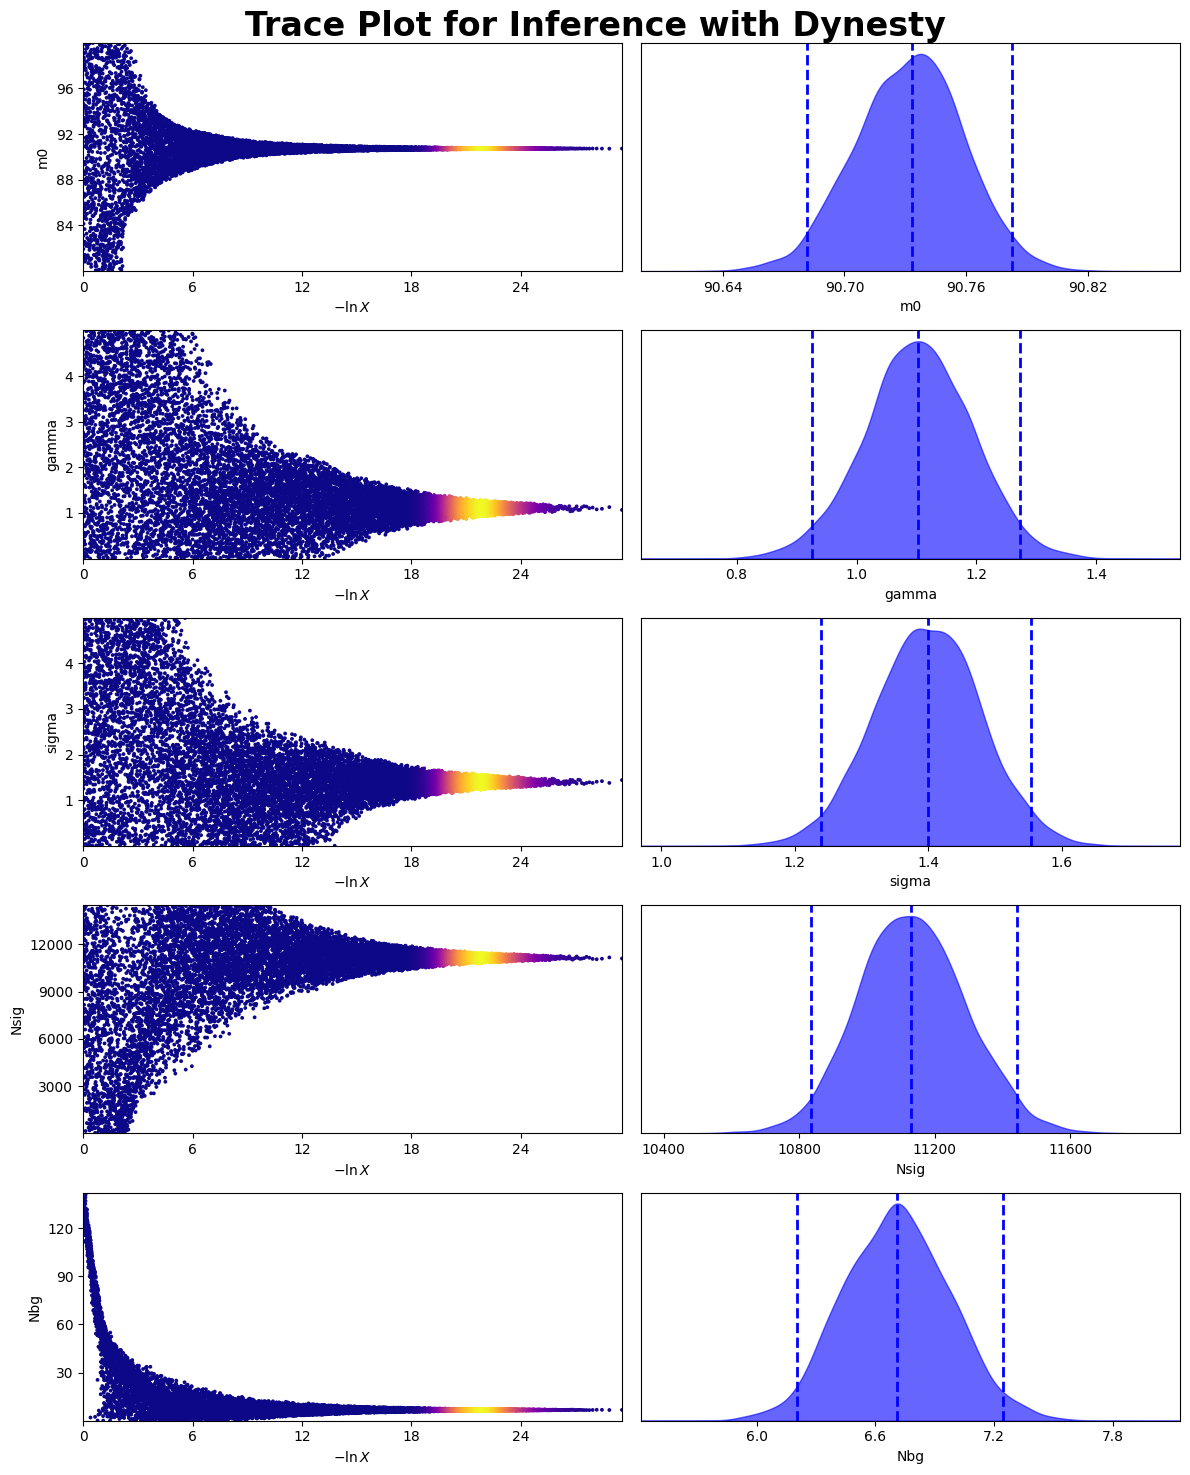

In [11]:
# Trace Plot
figt, axest = dyplot.traceplot(results, labels=param_labels)
figt.suptitle("Trace Plot for Inference with Dynesty", fontsize=24, fontweight='bold')
figt.tight_layout()
plt.show()

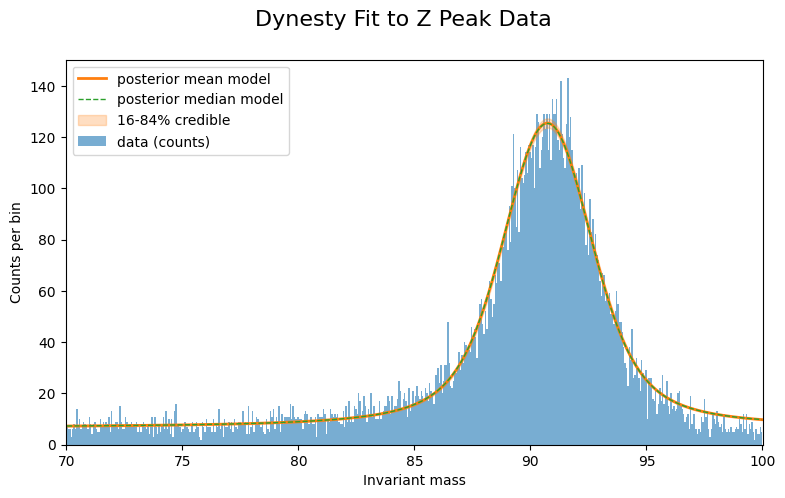

In [12]:
# Uncertainty band from posterior samples (weighted draw)
n_draw = 500
rng = np.random.default_rng(12345)
indices = rng.choice(len(samples), size=n_draw, replace=True, p=w)
models = []
for idx in indices:
    p = samples[idx]
    # model returns counts per bin directly
    models.append(model(x, p[0], p[1], p[2], p[3], p[4]))
models = np.vstack(models)
lower = np.percentile(models, 16, axis=0)
upper = np.percentile(models, 84, axis=0)
median = np.percentile(models, 50, axis=0)

# Plot the fitted models vs the observed data
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x, obs, width=width, align='center', alpha=0.6, label='data (counts)')
ax.plot(x, model_mean, color='C1', lw=2, label='posterior mean model')
ax.plot(x, median, color='C2', lw=1, ls='--', label='posterior median model')
ax.fill_between(x, lower, upper, color='C1', alpha=0.25, label='16-84% credible')
ax.set_xlabel('Invariant mass')
ax.set_ylabel('Counts per bin')
ax.legend()
ax.set_xlim(x.min() - width, x.max() + width)
fig.suptitle('Dynesty Fit to Z Peak Data', fontsize=16)
figt.tight_layout()
plt.show()